In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('sdg_index_2000-2022.csv') 
# df.head()

# avg_sdg_by_country = df.groupby('country')['sdg_index_score'].mean().reset_index() 
# avg_sdg_by_country.columns = ['country', 'avg_sdg_index'] 
 
# print("=== Топ-10 стран по среднему индексу SDG ===") 
# print(avg_sdg_by_country.sort_values('avg_sdg_index', ascending=False).head(10))

pivot_sdg = df.pivot_table(values='sdg_index_score', index='country', columns='year', 
aggfunc='mean') 
print("\nСводная таблица SDG индекса (первые 5 стран):") 
print(pivot_sdg.head()) 


Сводная таблица SDG индекса (первые 5 стран):
year         2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  ...  \
country                                                                  ...   
Afghanistan  36.0  36.3  36.3  36.7  37.1  37.5  37.6  38.0  37.3  38.3  ...   
Albania      65.9  65.9  65.7  65.7  66.2  66.5  66.6  66.8  67.5  68.0  ...   
Algeria      65.3  66.1  66.0  66.6  67.2  67.7  68.4  68.3  68.3  68.8  ...   
Angola       47.8  47.7  47.4  47.8  47.7  47.8  48.6  49.0  51.4  50.9  ...   
Argentina    66.2  66.1  66.3  66.7  67.0  67.8  67.9  68.1  68.3  69.3  ...   

year         2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  
country                                                                  
Afghanistan  39.7  40.8  41.6  44.7  45.6  46.3  46.4  47.3  46.3  49.0  
Albania      70.6  69.6  70.9  71.1  71.9  73.5  73.7  73.7  73.7  73.5  
Algeria      71.2  71.8  72.2  71.9  72.0  71.7  70.8  71.3  71.0  70.8  
Angola       53.1  52.

In [10]:

df = pd.read_csv('sdg_index_2000-2022.csv') 
goal9_summary  =  df.groupby('country')['goal_9_score'].agg(['mean',  'min',  'max', 
'count']).reset_index() 
goal9_summary.columns  =  ['country',  'avg_goal9',  'min_goal9',  'max_goal9', 
'years_observed'] 
 
print("\n=== Сводная статистика по Goal 9 для каждой страны ===") 
print(goal9_summary.sort_values('avg_goal9', ascending=False).head(10))


=== Сводная статистика по Goal 9 для каждой страны ===
           country  avg_goal9  min_goal9  max_goal9  years_observed
155         Sweden  94.330435       87.0       98.5              23
84     Korea, Rep.  90.439130       71.0       99.2              23
80           Japan  89.691304       78.7       94.6              23
56         Finland  89.108696       75.9       97.4              23
44         Denmark  88.208696       71.7       97.0              23
156    Switzerland  87.169565       75.8       97.2              23
170  United States  86.721739       74.3       97.8              23
6        Australia  86.552174       77.6       92.2              23
122         Norway  85.930435       77.4       92.4              23
143      Singapore  85.582609       74.5       91.5              23


In [ ]:
# Самостоятельное задание 1 
# Рассчитайте  средний  показатель  goal_9_score  (инновации)  за  последние  5  лет 
# (2019–2023)  для  стран  Скандинавии  (например,  Sweden,  Norway,  Finland, 
# Denmark). Постройте сводную таблицу по этим странам и годам. 

scandinavian = ['Sweden', 'Norway', 'Finland', 'Denmark']
df_scand = df[df['country'].isin(scandinavian) & df['year'].between(2019, 2023)]

avg_goal9 = df_scand.groupby('country')['goal_9_score'].mean().reset_index()
avg_goal9.columns = ['country', 'avg_goal9_2019_2023']
print("=== Средний Goal 9 (2019–2023), Скандинавия ===")
print(avg_goal9.sort_values('avg_goal9_2019_2023', ascending=False))

pivot_scand = df_scand.pivot_table(values='goal_9_score', index='country', columns='year', aggfunc='mean')
print("\n=== Сводная таблица Goal 9 по странам и годам ===")
print(pivot_scand)

=== Средний Goal 9 (2019–2023), Скандинавия ===
   country  avg_goal9_2019_2023
3   Sweden               97.925
0  Denmark               96.800
1  Finland               95.725
2   Norway               92.200

=== Сводная таблица Goal 9 по странам и годам ===
year     2019  2020  2021  2022
country                        
Denmark  96.6  96.6  97.0  97.0
Finland  95.0  95.9  96.0  96.0
Norway   91.8  92.2  92.4  92.4
Sweden   98.0  98.5  97.6  97.6


Средний sdg_index_score (Germany, 2020–2023): 83.23


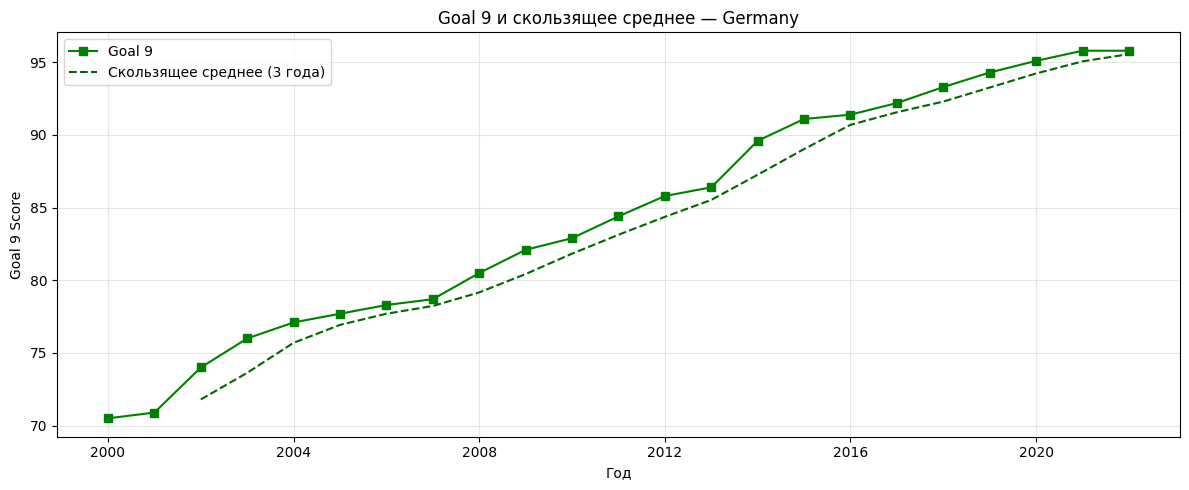

In [ ]:
# Самостоятельное задание 2 
# Для выбранной вами страны: 
# Рассчитайте средний sdg_index_score за 2020–2023 гг. Выполните ресемплинг по 
# годам  (даже  если  данные  уже  годовые).  Рассчитайте  скользящее  среднее  для 
# goal_9_score  с  окном  3.  Постройте  график,  сравнивающий  goal_9_score  и  его 
# скользящее среднее. 

selected_country = "Germany"
df_country = df[df['country'] == selected_country].copy()
df_country = df_country.sort_values('year').reset_index(drop=True)

avg_sdg_2020_2023 = df_country[df_country['year'].between(2020, 2023)]['sdg_index_score'].mean()
print(f"Средний sdg_index_score ({selected_country}, 2020–2023): {avg_sdg_2020_2023:.2f}")

df_country['year_dt'] = pd.to_datetime(df_country['year'], format='%Y')
df_country.set_index('year_dt', inplace=True)

yearly_resample = df_country['sdg_index_score'].resample('YE').mean()

df_country['rolling_3y_goal9'] = df_country['goal_9_score'].rolling(window=3).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_country.index, df_country['goal_9_score'], marker='s', color='green', label='Goal 9')
plt.plot(df_country.index, df_country['rolling_3y_goal9'], linestyle='--', color='darkgreen', label='Скользящее среднее (3 года)')
plt.title(f'Goal 9 и скользящее среднее — {selected_country}')
plt.xlabel('Год')
plt.ylabel('Goal 9 Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()